# EN3160 — Assignment 01

## Intensity Transformations and Neighborhood Filtering

**Deshan W.U.**  
**230130E**

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [14]:
# Import Emma image
emma = cv.imread('images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert emma is not None

In [15]:
# Define piecewise transformation function
t1 = np.linspace(0, 50, num=51).astype('uint8')
t2 = np.linspace(100, 255, num=100).astype('uint8')
t3 = np.linspace(150, 255, num=105).astype('uint8')

# Concatenate all segments to create the transformation array
t = np.concatenate((t1, t2, t3), axis=0).astype('uint8')
print(t.shape)

(256,)


*Plot the transformation*

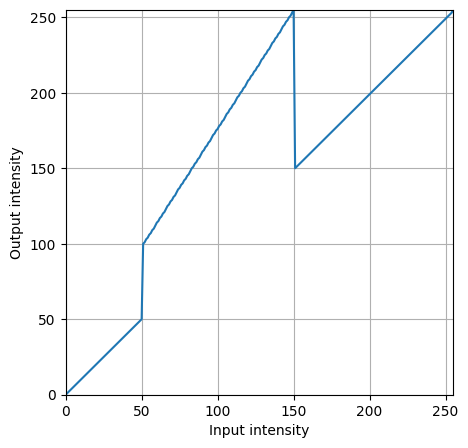

In [16]:
plt.figure(figsize=(5, 5))
plt.plot(t)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()

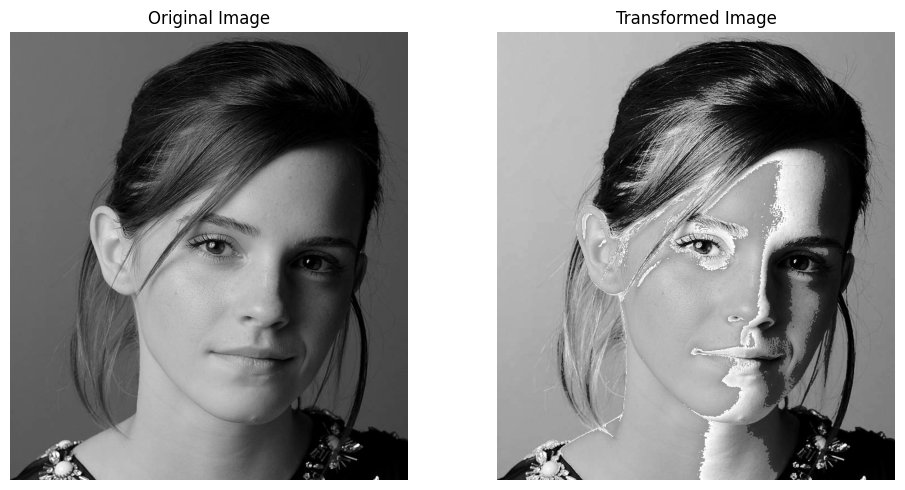

In [17]:
g = t[emma]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(emma, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis('off')

plt.tight_layout()
plt.show()

### Question 2

In [18]:
# Import brain image
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)
assert brain is not None

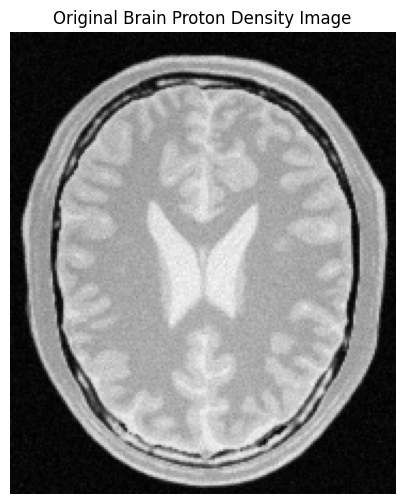

In [20]:
# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(brain, cmap='gray', vmin=0, vmax=255)
plt.title("Original Brain Proton Density Image")
plt.axis("off")
plt.show()

a) white matter

(256,)


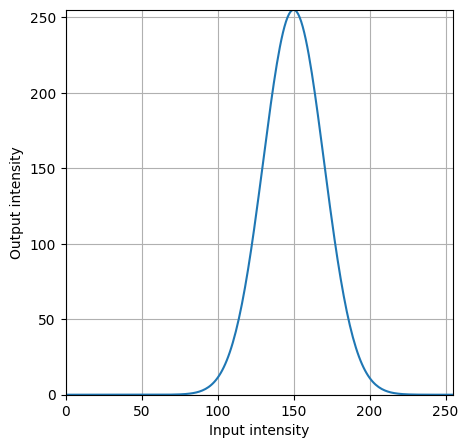

In [34]:
# Define the gaussian pulse
mu = 150
sigma = 20
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Ensure the output is in the valid range for image intensities [0, 255]
t = np.clip(t, 0, 255)

print(t.shape)

# Plot the array
plt.figure(figsize=(5, 5))
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

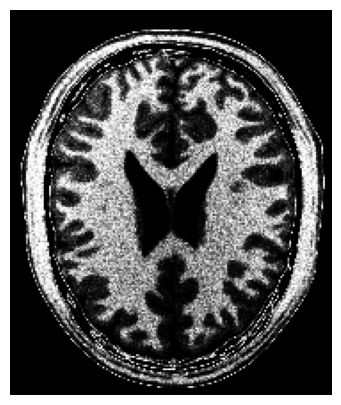

In [35]:
g = t[brain]

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

b) gray matter

(256,)


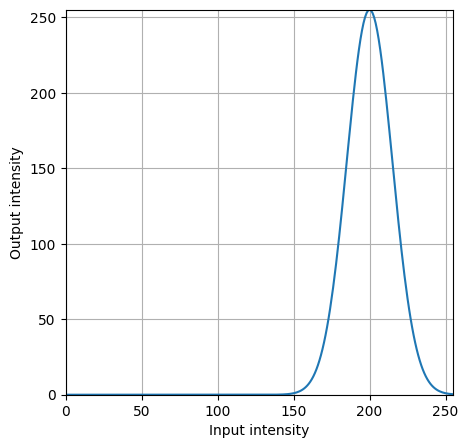

In [36]:
mu = 200
sigma = 15
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Ensure the output is in the valid range for image intensities [0, 255]
t = np.clip(t, 0, 255)

print(t.shape)

# Plot the array
plt.figure(figsize=(5, 5))
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

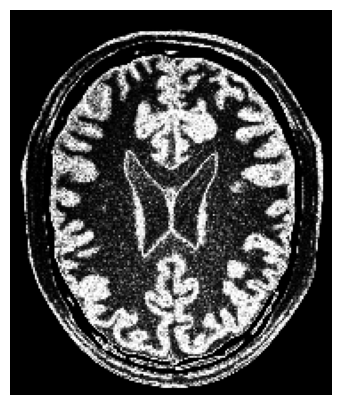

In [37]:
# Apply transformation
g = t[brain]

# Display transformed image
plt.figure(figsize=(5, 5))
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Question 3

In [51]:
# Import  image
girl = cv.imread('images/girl.jpeg')
assert girl is not None

In [61]:
lab = cv.cvtColor(girl, cv.COLOR_BGR2LAB)
girl_rgb = cv.cvtColor(girl, cv.COLOR_BGR2RGB)
L, a, b = cv.split(lab)
L_norm = L.astype(np.float32) / 255.0

In [63]:
#Apply gamma correction
gamma = 0.75
L_corrected = np.power(L_norm, gamma)
L_corrected = np.clip(L_corrected * 255,0,255).astype(np.uint8)
lab_corrected = lab.copy()
lab_corrected[:, :, 0] = L_corrected
rgb_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

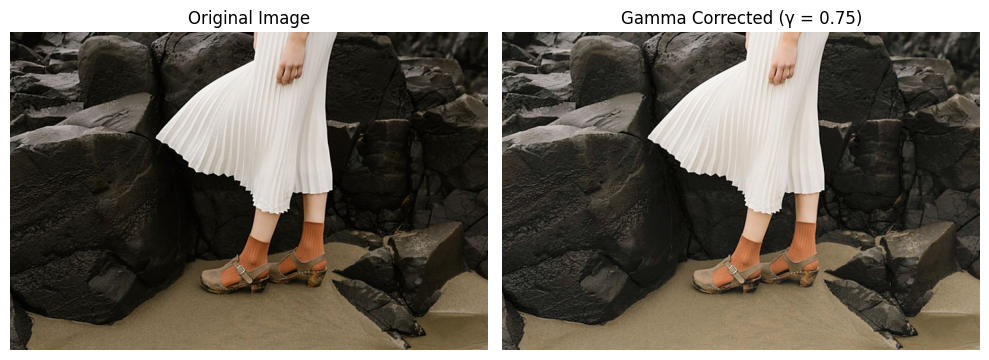

In [65]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(girl_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgb_corrected)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

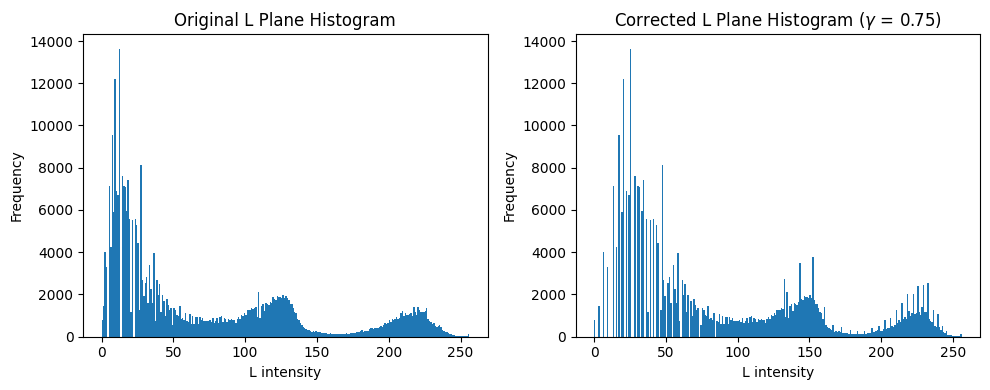

In [69]:
# Histograms of L plane before and after gamma correction

plt.figure(figsize=(10, 4))

# Original L plane histogram
plt.subplot(1, 2, 1)

plt.hist(
    L.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title("Original L Plane Histogram")


# L plane histogram after gamma correction
plt.subplot(1, 2, 2)

plt.hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected L Plane Histogram ($\\gamma$ = {gamma})")

plt.tight_layout()
plt.show()

### Question 4

In [3]:
# Import image
peter = cv.imread('images/peter.png')
assert peter is not None
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)
peter_rgb = cv.cvtColor(peter, cv.COLOR_BGR2RGB)

# Split into planes
H, S, V = cv.split(peter_hsv)

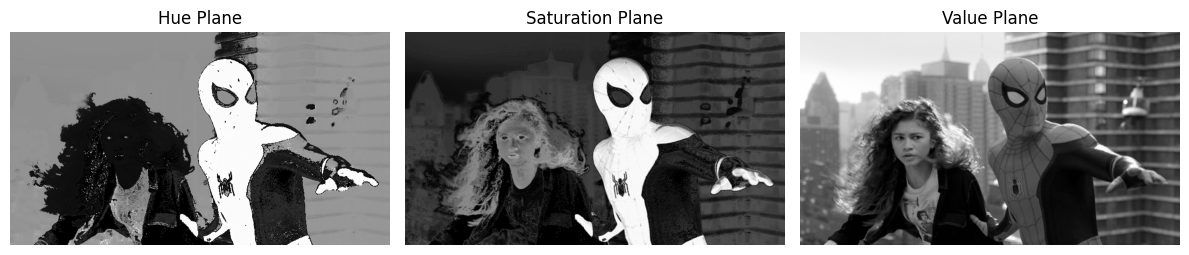

In [6]:
# Display the planes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(H, cmap='gray')
axs[0].set_title('Hue Plane')
axs[0].axis('off')

axs[1].imshow(S, cmap='gray')
axs[1].set_title('Saturation Plane')
axs[1].axis('off')

axs[2].imshow(V, cmap='gray')
axs[2].set_title('Value Plane')
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Define the transformation function
a = 0.7
sigma = 70.0 
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')

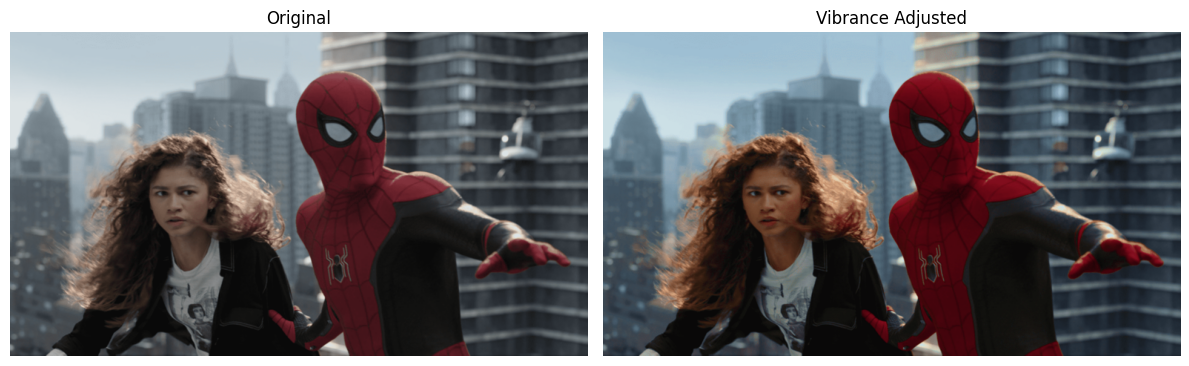

In [8]:
# Apply transformation to Saturation plane
S_modified = cv.LUT(S, f)

# Merge H, modified S, and V planes
merged = cv.merge([H, S_modified, V])

# Convert HSV to RGB
peter_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)

# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Original image
axs[0].imshow(peter_rgb)
axs[0].set_title('Original')
axs[0].axis('off')

# Saturation-adjusted image
axs[1].imshow(peter_modified)
axs[1].set_title('Vibrance Adjusted')
axs[1].axis('off')

# Show the plot
plt.tight_layout()
plt.show()

By fine-tuning the parameter a, several values were tested to obtain a visually pleasing output. After comparing the resulting images, a = 0.6 was selected as the best value. This value provided an appropriate enhancement of the image saturation while maintaining a natural appearance.

### Question 5

In [9]:
# Import Shells image
beans = cv.imread('images/beans.png', cv.IMREAD_GRAYSCALE)
assert beans is not None

In [14]:
def histogram_equalization(f):
    # Get image details
    L = 256
    M, N = f.shape

    # Get histogram
    hist = cv.calcHist([f], [0], None, [L], [0, L])
    cdf = hist.cumsum()

    # Define transformation
    t = np.array([(L-1)/(M*N)*cdf[k] for k in range(256)]).astype("uint8")

    return t[f]

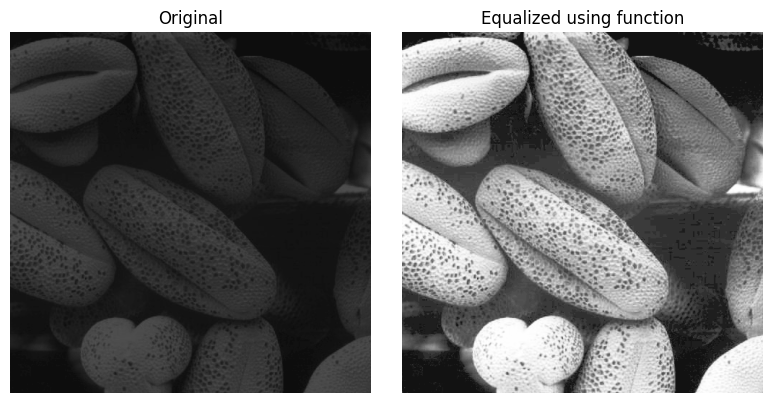

In [18]:
# Do histrogram equalization
equalized = histogram_equalization(beans)

# Create the figure for plotting
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(beans, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")

# Show the plot
plt.tight_layout()
plt.show()

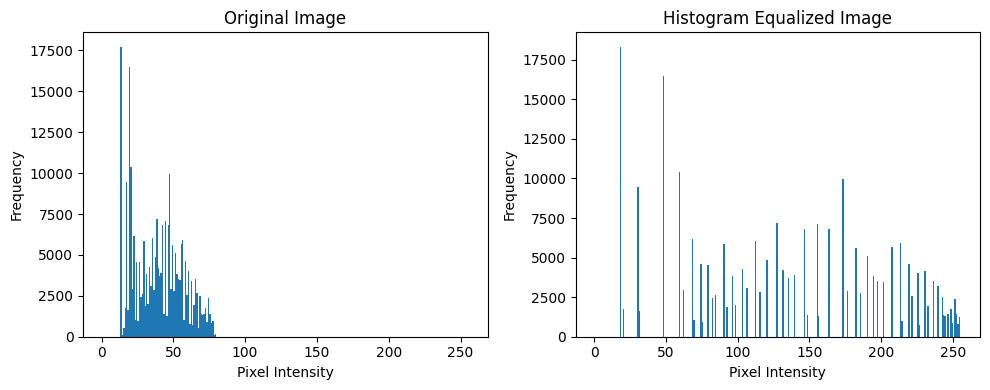

In [20]:
# Display histograms
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(beans.ravel(), bins=256, range=(0, 256))
ax[0].set_title('Original Image')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')

ax[1].hist(equalized.ravel(), bins=256, range=(0, 256))
ax[1].set_title('Histogram Equalized Image')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()